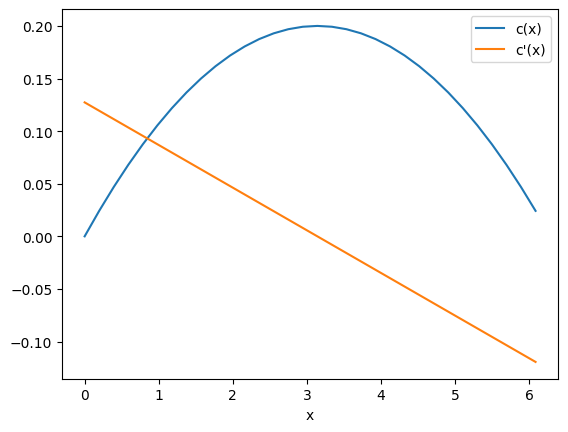

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5
N = 2**n_qubits
L = 2 * np.pi               
t = 5     
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x 
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L 


plt.plot(x, c, label='c(x)')
plt.plot(x, cx, label='c\'(x)')
plt.xlabel('x')
plt.legend()


sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)

In [2]:
# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

In [3]:
def advection_sol(t, useFixedJ=False, fixed_J=64):
    final_time = t
    eps_lchs = 1e-3
    eps_quad = 1e-3
    c_lchs = 1

    # 1. Define the original Hermitian operator
    H_herm_raw = cx / 2
    
    # 2. Find the minimum eigenvalue (the most negative point of the derivative)
    min_eigenvalue = np.min(H_herm_raw)
    
    # 3. Apply the shift ONLY if there are negative eigenvalues
    if min_eigenvalue < 0:
        lambda_shift = np.abs(min_eigenvalue)
        print(f"Applying shift of {lambda_shift:.4f} to ensure positive semidefiniteness.")
    else:
        lambda_shift = 0
        
    # 4. Create the strictly positive semidefinite operator
    H_herm = H_herm_raw + lambda_shift
    j_indices = np.arange(N)
    k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
    P_1 = 1j * (2 * np.pi / L) * (k_indices)

    qft, qft_inv = get_qft_mat(n_qubits)
    Delta = qft_inv @ np.diag(P_1) @ qft 

    norm = t * np.max(cx)/2 
    h = np.pi / (norm/2 + np.log(64*np.exp(3*c_lchs/2)/(15*eps_quad)))
    gamma = 1/c_lchs * np.sqrt(c_lchs+np.log((1+1/(2*np.pi))/eps_lchs))
    if useFixedJ:
        J = fixed_J
        R = J * h
        num_terms = 2*J
    else:
        R = 2*c_lchs*gamma**2
        J = R/h
        print(f"J: {J}")

        J_int = int(2**(np.floor(np.log2(J))))
        R = J_int * h
        print(f"J_int: {J_int}")
        print(f"R: {R}, h: {h}, gamma: {gamma}")

        J = J_int
        num_terms = 2*J_int
    n_ancilla = int(np.log2(num_terms))

    # Creates exactly num_terms points: [-J, -J+1, ..., J-1]
    j_vals = np.arange(-J, J) 
    k_vals = h * j_vals
    weights = (h / np.sqrt(2*np.pi)) * np.exp(c_lchs*(1-1j*k_vals)) * np.exp(-(k_vals**2+1)/(4*gamma**2)) / (1 + k_vals**2)

    magnitudes = np.abs(weights)
    phases = np.angle(weights)

    coeffs = np.sqrt(magnitudes)
    coeffs = coeffs / np.linalg.norm(coeffs)         


    # ... [Keep all your initialization code up to Section A] ...

    r_steps = 100
    dt = final_time / r_steps
    sqrt_dt = np.sqrt(dt)

    # --- SETUP LCU DIAGONAL FOR dt (Not final_time) ---
    select_diagonal_dt = np.ones(2**(n_ancilla + n_qubits), dtype=complex)
    for i in range(num_terms):
        # CRITICAL FIX: Use dt here instead of final_time
        U_diag = np.exp(1j * phases[i]) * np.exp(-1j * dt * H_herm * k_vals[i])
        for sys_idx in range(N):
            idx = (sys_idx << n_ancilla) + i
            select_diagonal_dt[idx] = U_diag[sys_idx]

    # --- SETUP TROTTER STEP FOR SKEW-HERMITIAN PART ---
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    A = -np.diag(c) / 2
    B = Delta  
    A_tilde = np.kron(A, Y)
    B_tilde = np.kron(B, X)

    # Compute a SINGLE Trotter step
    step_1 = expm(-1j * sqrt_dt * A_tilde)
    step_2 = expm(sqrt_dt * B_tilde)
    step_3 = expm(1j * sqrt_dt * A_tilde)
    step_4 = expm(-sqrt_dt * B_tilde)
    U_step = step_4 @ step_3 @ step_2 @ step_1 
    # CRITICAL FIX: Do not raise to matrix_power(r_steps) here!

    # ==== 4. CIRCUIT CONSTRUCTION ====
    reg_a = QuantumRegister(n_ancilla, 'lchs_ancilla') 
    reg_ca = QuantumRegister(1, 'commutator_ancilla') 
    reg_s = QuantumRegister(n_qubits, 'system')
    circuit = QuantumCircuit(reg_a, reg_ca, reg_s)

    # Initialize System State
    sigma = L/20
    state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
    state = state / np.linalg.norm(state)
    stateprep = StatePreparation(state)
    circuit.append(stateprep, reg_s)

    # --- 1. OPEN LCU SUPERPOSITION ---
    prep_gate = StatePreparation(coeffs)
    circuit.append(prep_gate, reg_a)

    # --- 2. THE TROTTER LOOP ---
    for _ in range(r_steps):
        # A. Apply w-dependent Hermitian step (Controlled by LCHS ancillas)
        circuit.append(DiagonalGate(select_diagonal_dt), list(reg_a) + list(reg_s))
        
        # B. Apply w-independent Skew-Hermitian step (Uncontrolled by LCHS, uses Commutator ancilla)
        circuit.append(UnitaryGate(U_step), [reg_ca[0]] + list(reg_s))

    # --- 3. CLOSE LCU SUPERPOSITION ---
    circuit.append(prep_gate.inverse(), reg_a)

    # ==== 5. SIMULATION & POST-SELECTION ====
    final_state = Statevector(circuit)
    full_data = np.array(final_state)

    # Qiskit ordering: reg_s (MSB) | reg_ca | reg_a (LSB)
    # Total ancillas = n_ancilla (LCHS) + 1 (Commutator)
    # We post-select the state where all (n_ancilla + 1) ancillas are exactly |0>
    system_state = full_data[0::2**(n_ancilla + 1)]

    success_prob = np.linalg.norm(system_state)**2
    print(f"Success Probability: {success_prob:.4e}")
    final = system_state / np.linalg.norm(system_state)
    return final


<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_130035/3455960336.py:55: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')


Applying shift of 0.0597 to ensure positive semidefiniteness.
Success Probability: 1.4290e-01
Error: 3.4526e-02
Applying shift of 0.0597 to ensure positive semidefiniteness.
Success Probability: 2.1783e-01
Error: 8.1856e-02
Applying shift of 0.0597 to ensure positive semidefiniteness.
Success Probability: 3.3623e-01
Error: 9.8942e-02


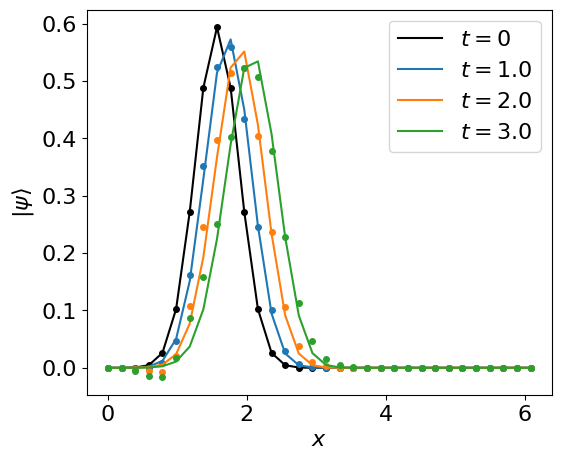

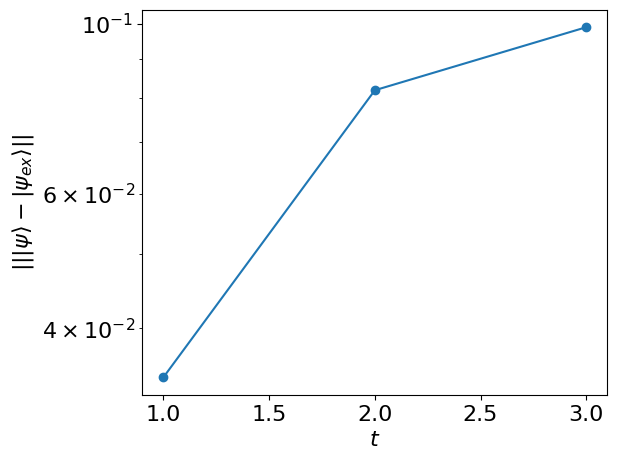

In [4]:
n_qubits = 5
N = 2**n_qubits
L = 2*np.pi 
x = np.linspace(0, L, N, endpoint=False)
dx = L / N
ts = [1, 2, 3]

# Initial State: Gaussian centered in the middle
sigma = L/20
state = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state = state / np.linalg.norm(state)



plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6, 5), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()
plt.plot(x, state, 'ko',  markersize=4)
plt.plot(x, state, 'k-', label='$t=0$')

errs = []
for t in ts:

    final = advection_sol(t=t, useFixedJ=True, fixed_J=128)


    # Exact Solution 
    QFT, QFT_inv = get_qft_mat(n_qubits)
    j_indices = np.arange(N)
    k_j = 2*np.pi /L * np.where(j_indices < N/2, j_indices, j_indices - N)
    P1 = np.diag(1j*k_j)
    P2 = np.diag(-k_j**2)
    D1 = QFT_inv @ P1 @ QFT
    D2 = QFT_inv @ P2 @ QFT

    A = - (-0.5 * (D1 @ np.diag(c) + np.diag(c) @ D1) - 0.5 * np.diag(cx))

    exact_final = expm(-A * t) @ state
    exact_final = exact_final / np.linalg.norm(exact_final)

    # Error Calculation
    err = np.linalg.norm(np.real(exact_final) - np.real(final))
    errs.append(err)
    print(f"Error: {err:.4e}")

    line, = plt.plot(x, np.real(final), 'o',  markersize=4)
    color = line.get_color()
    plt.plot(x, np.real(exact_final), '-',  label=f'$t={t:.1f}$',color=color, )
plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.legend(loc='upper center', ncol=3, fontsize=14)
plt.legend()
#plt.savefig('./figures/lcu_kernel_lchs_advection_parabolic_c.pdf', bbox_inches='tight')
plt.show()


plt.rcParams.update({
    "font.size": 16,
    "figure.figsize": (6, 5), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure() 
plt.semilogy(ts, errs, 'o-')
plt.xlabel('$t$ ')
plt.ylabel('$|||\\psi\\rangle- |\\psi_{ex}\\rangle ||$')
#plt.savefig('./figures/advection_error_vs_time.pdf', bbox_inches='tight')
plt.show()



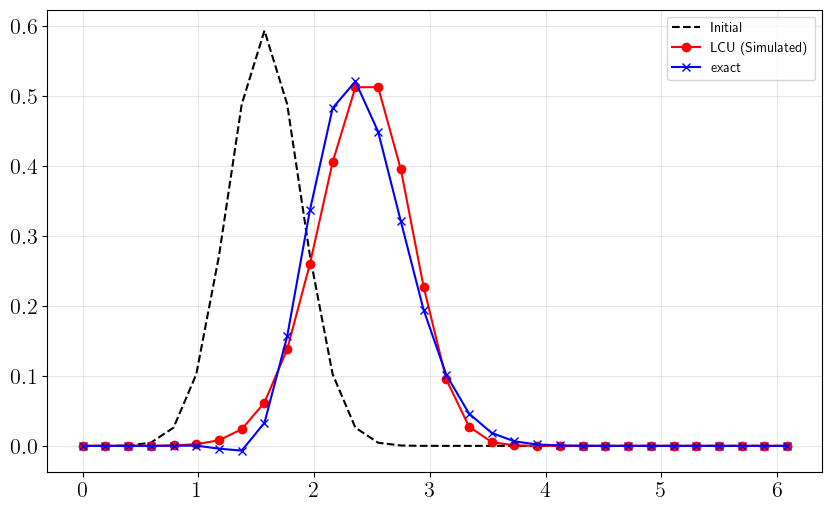

In [19]:



gamma_s = 1.0 / (2 * dx)


c_left = np.roll(c, 1)    # index i contains c_{i-1}
c_right = np.roll(c, -1)  # index i contains c_{i+1}

val_lower = gamma_s * c_left
val_upper = -gamma_s * c_right


M = np.diag(val_lower[1:], k=-1) + np.diag(val_upper[:-1], k=1)
M[0, N-1] = val_lower[0]
M[N-1, 0] = val_upper[N-1]
u_final = expm(M * t) @ state

u_final = u_final / np.linalg.norm(u_final)

final = final / np.linalg.norm(final)


plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
xx = np.linspace(0, L, 2**5, endpoint=False)
plt.plot(xx, np.real(final), 'ro-', label=f'LCU (Simulated)')
plt.plot(x, u_final/np.linalg.norm(u_final), 'bx-', label=f'exact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()